In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import pandas as pd

from aicsimageio import AICSImage, readers

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib.font_manager as font_manager

25-Jun-26 13:50:50 - bfio.backends - WARNING  - Java backend is not available. This could be due to a missing dependency (jpype).


In [3]:
font_path = "/srv/scratch/berrylab/z3532965/font/Arial.ttf"
font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams['font.family'] = font_name

plt.rcParams['svg.fonttype'] = 'none'

## load layouts from file

In [4]:
Experiment1Layout = pd.read_csv("/srv/scratch/z3532965/src/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/mACPOLR2A_CRC_EU/260508_mACPOLR2A_CRC_EU/METADATA/260508_mACPOLR2A_CRC_EU.csv")
Experiment2Layout = pd.read_csv("/srv/scratch/z3532965/src/publications/2026_POLR2A_homeostasis/Imaging/NikonSpinningDisk/mACPOLR2A_CRC_EU/260515_mACPOLR2A_CRC_EU/METADATA/260515_mACPOLR2A_CRC_EU.csv")

## load quantification files from relevant directories, and assemble into data frames

In [5]:
Experiment1_Quantification_Directory_Cycle1 = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/260508_mACPOLR2A_CRC_EU/20260512_172454_996/QUANTIFICATION")
Experiment1_Quantification_Files_Cycle1 = glob.glob(str(Experiment1_Quantification_Directory_Cycle1 / "*.csv"))

Experiment1_Quantification_Directory_Cycle2 = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/260508_mACPOLR2A_CRC_EU/20260513_172852_341/QUANTIFICATION/")
Experiment1_Quantification_Files_Cycle2 = glob.glob(str(Experiment1_Quantification_Directory_Cycle2 / "*.csv"))

Experiment2_Quantification_Directory_Cycle1 = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/260515_mACPOLR2A_CRC_EU/20260518_174459_919/QUANTIFICATION/")
Experiment2_Quantification_Files_Cycle1 = glob.glob(str(Experiment2_Quantification_Directory_Cycle1 / "*.csv"))

Experiment2_Quantification_Directory_Cycle2 = Path("/srv/scratch/berrylab/z3536241/NikonSpinningDisk/260515_mACPOLR2A_CRC_EU/20260519_171947_338/QUANTIFICATION/")
Experiment2_Quantification_Files_Cycle2 = glob.glob(str(Experiment2_Quantification_Directory_Cycle2 / "*.csv"))

In [6]:
[len(y) for y in [Experiment1_Quantification_Files_Cycle1, Experiment1_Quantification_Files_Cycle2, Experiment2_Quantification_Files_Cycle1, Experiment2_Quantification_Files_Cycle2]]

[959, 960, 960, 960]

### experiment 1

In [7]:
qdfs = list()


for f in tqdm(Experiment1_Quantification_Files_Cycle1):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment1_Cycle1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment1_Cycle1_PerCell['file'].tolist()


wellnames = [f[11:14] for f in files]
Experiment1_Cycle1_PerCell['well'] = wellnames

fovs = [f[47:51] for f in files]
Experiment1_Cycle1_PerCell['fov'] = fovs

Intensities_Experiment1_Cycle1 = pd.DataFrame({
    "WELL" : Experiment1_Cycle1_PerCell['well'],
    "GFP_Intensity" : Experiment1_Cycle1_PerCell['Channel:0:0_intensity_mean_488'],
    "DAPI_Intensity" : Experiment1_Cycle1_PerCell['Channel:0:0_intensity_mean_405'],
    "NucleusArea" : Experiment1_Cycle1_PerCell['Channel:0:0_area']
})

100%|██████████| 959/959 [00:25<00:00, 37.36it/s]


In [8]:
qdfs = list()


for f in tqdm(Experiment1_Quantification_Files_Cycle2):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment1_Cycle2_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment1_Cycle2_PerCell['file'].tolist()


wellnames = [f[11:14] for f in files]
Experiment1_Cycle2_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment1_Cycle2_PerCell['fov'] = fovs

Intensities_Experiment1_Cycle2 = pd.DataFrame({
    "WELL" : Experiment1_Cycle2_PerCell['well'],
    "EU_647_Intensity" : Experiment1_Cycle2_PerCell['Channel:0:0_intensity_mean_647'],
    "IF_568_Intensity" : Experiment1_Cycle2_PerCell['Channel:0:0_intensity_mean_561'],
    "DAPI_Intensity_2" : Experiment1_Cycle2_PerCell['Channel:0:0_intensity_mean_405'],
    "NucleusArea_2" : Experiment1_Cycle2_PerCell['Channel:0:0_area']
})

100%|██████████| 960/960 [00:26<00:00, 35.57it/s]


In [9]:
qdfs = list()


for f in tqdm(Experiment2_Quantification_Files_Cycle1):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment2_Cycle1_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment2_Cycle1_PerCell['file'].tolist()


wellnames = [f[11:14] for f in files]
Experiment2_Cycle1_PerCell['well'] = wellnames

fovs = [f[47:51] for f in files]
Experiment2_Cycle1_PerCell['fov'] = fovs

Intensities_Experiment2_Cycle1 = pd.DataFrame({
    "WELL" : Experiment2_Cycle1_PerCell['well'],
    "GFP_Intensity" : Experiment2_Cycle1_PerCell['Channel:0:0_intensity_mean_488'],
    "DAPI_Intensity" : Experiment2_Cycle1_PerCell['Channel:0:0_intensity_mean_405'],
    "NucleusArea" : Experiment2_Cycle1_PerCell['Channel:0:0_area']
})

100%|██████████| 960/960 [00:25<00:00, 37.61it/s]


In [10]:
qdfs = list()


for f in tqdm(Experiment2_Quantification_Files_Cycle2):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment2_Cycle2_PerCell = pd.concat(qdfs, ignore_index=True)

files = Experiment2_Cycle2_PerCell['file'].tolist()


wellnames = [f[11:14] for f in files]
Experiment2_Cycle2_PerCell['well'] = wellnames

fovs = [f[39:43] for f in files]
Experiment2_Cycle2_PerCell['fov'] = fovs

Intensities_Experiment2_Cycle2 = pd.DataFrame({
    "WELL" : Experiment2_Cycle2_PerCell['well'],
    "EU_647_Intensity" : Experiment2_Cycle2_PerCell['Channel:0:0_intensity_mean_647'],
    "IF_568_Intensity" : Experiment2_Cycle2_PerCell['Channel:0:0_intensity_mean_561'],
    "DAPI_Intensity_2" : Experiment2_Cycle2_PerCell['Channel:0:0_intensity_mean_405'],
    "NucleusArea_2" : Experiment2_Cycle2_PerCell['Channel:0:0_area']
})

100%|██████████| 960/960 [00:25<00:00, 37.74it/s]


## average by individual wells, add cell counts, and merge with layouts,

In [11]:
CountsByWell1 = Intensities_Experiment1_Cycle1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell1.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment1_Cycle1 = Intensities_Experiment1_Cycle1.groupby('WELL').mean().reset_index().merge(Experiment1Layout, how = 'left')
IntensitiesByWell_Experiment1_Cycle1 = IntensitiesByWell_Experiment1_Cycle1.merge(CountsByWell1)
IntensitiesByWell_Experiment1_Cycle2 = Intensities_Experiment1_Cycle2.groupby('WELL').mean().reset_index()

IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1_Cycle1.merge(IntensitiesByWell_Experiment1_Cycle2, how = 'left', left_on = "WELL", right_on = "WELL")
IntensitiesByWell_Experiment1['EXPERIMENT'] = '260508_mACPOLR2A_CRC_EU'

In [12]:
CountsByWell2 = Intensities_Experiment2_Cycle1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell2.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)
IntensitiesByWell_Experiment2_Cycle1 = Intensities_Experiment2_Cycle1.groupby('WELL').mean().reset_index().merge(Experiment2Layout, how = 'left')
IntensitiesByWell_Experiment2_Cycle1 = IntensitiesByWell_Experiment2_Cycle1.merge(CountsByWell1)
IntensitiesByWell_Experiment2_Cycle2 = Intensities_Experiment2_Cycle2.groupby('WELL').mean().reset_index()

IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2_Cycle1.merge(IntensitiesByWell_Experiment2_Cycle2, how = 'left', left_on = "WELL", right_on = "WELL")
IntensitiesByWell_Experiment2['EXPERIMENT'] = '260515_mACPOLR2A_CRC_EU'

## examine raw data per experiment

In [13]:
IntensitiesByWell_Experiment1.CELL.unique(), IntensitiesByWell_Experiment1.PRIMARY.unique(), IntensitiesByWell_Experiment1.DRUG_CONCENTRATION.unique()

(array(['HCT116 OsTIRF74G', 'HCT116 OsTIRF74G mAC-POLR2A Clone 5'],
       dtype=object),
 array(['Nucleolin (D4C7O) ', 'Total Pol II (F12)', 'No primary'],
       dtype=object),
 array([   0, 1000,  300,  100,   30,   10,    3]))

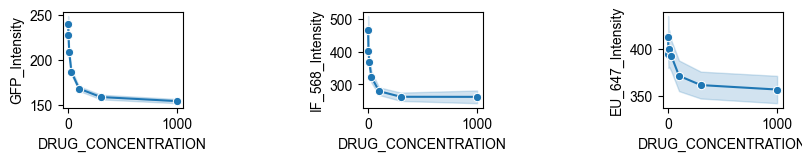

In [14]:
f, a = plt.subplots(ncols = 3, figsize = (9,1.5), layout = 'constrained')

sns.lineplot(IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
             x = 'DRUG_CONCENTRATION',
             y = 'GFP_Intensity',
             marker = 'o',
             errorbar = 'sd',
             ax = a[0])

sns.lineplot(IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & PRIMARY == "Total Pol II (F12)"'),
             x = 'DRUG_CONCENTRATION',
             y = 'IF_568_Intensity',
             marker = 'o',
             errorbar = 'sd',
             ax = a[1])

sns.lineplot(IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & EU == "EU 1 mM, 30 mins"'),
             x = 'DRUG_CONCENTRATION',
             y = 'EU_647_Intensity',
             marker = 'o',
             errorbar = 'sd',
             ax = a[2])

for i in range(3):
    a[i].set_box_aspect(0.8)
             

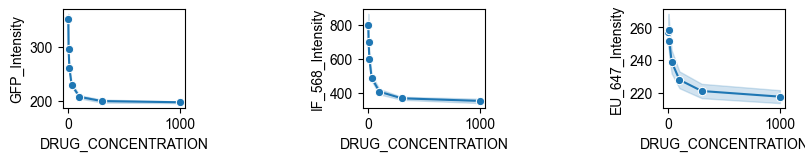

In [15]:
f, a = plt.subplots(ncols = 3, figsize = (9,1.5), layout = 'constrained')

sns.lineplot(IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
             x = 'DRUG_CONCENTRATION',
             y = 'GFP_Intensity',
             marker = 'o',
             errorbar = 'sd',
             ax = a[0])

sns.lineplot(IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & PRIMARY == "Total Pol II (F12)"'),
             x = 'DRUG_CONCENTRATION',
             y = 'IF_568_Intensity',
             marker = 'o',
             errorbar = 'sd',
             ax = a[1])

sns.lineplot(IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & EU == "EU 1 mM, 30 mins"'),
             x = 'DRUG_CONCENTRATION',
             y = 'EU_647_Intensity',
             marker = 'o',
             errorbar = 'sd',
             ax = a[2])

for i in range(3):
    a[i].set_box_aspect(0.8)
             

## background subtract and normalise within experiments

In [16]:
E1_GFP_Zero = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G"').GFP_Intensity.mean()
E2_GFP_Zero = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G"').GFP_Intensity.mean()

IntensitiesByWell_Experiment1['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment1['GFP_Intensity'] - E1_GFP_Zero
IntensitiesByWell_Experiment2['GFP_Intensity_BGS'] = IntensitiesByWell_Experiment2['GFP_Intensity'] - E2_GFP_Zero

E1_GFP_NV = IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG == "Vehicle"').GFP_Intensity_BGS.mean()
E2_GFP_NV = IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG == "Vehicle"').GFP_Intensity_BGS.mean()

IntensitiesByWell_Experiment1['GFP_Intensity_FC'] = IntensitiesByWell_Experiment1['GFP_Intensity_BGS'] / E1_GFP_NV
IntensitiesByWell_Experiment2['GFP_Intensity_FC'] = IntensitiesByWell_Experiment2['GFP_Intensity_BGS'] / E2_GFP_NV

IntensitiesByWell = pd.concat([IntensitiesByWell_Experiment1, IntensitiesByWell_Experiment2])

In [17]:
E1_Mouse_Zero = IntensitiesByWell_Experiment1.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-mouse Alexa568"').IF_568_Intensity.mean()
E2_Mouse_Zero = IntensitiesByWell_Experiment2.query('PRIMARY == "No primary" & SECONDARY == "Goat anti-mouse Alexa568"').IF_568_Intensity.mean()

Total_IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.query('PRIMARY == "Total Pol II (F12)"')
Total_IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.query('PRIMARY == "Total Pol II (F12)"')

Total_IntensitiesByWell_Experiment1['IF_Intensity_BGS'] = Total_IntensitiesByWell_Experiment1['IF_568_Intensity'] - E1_Mouse_Zero
Total_IntensitiesByWell_Experiment2['IF_Intensity_BGS'] = Total_IntensitiesByWell_Experiment2['IF_568_Intensity'] - E2_Mouse_Zero

E1_Total_NV = Total_IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG == "Vehicle"').IF_Intensity_BGS.mean()
E2_Total_NV = Total_IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG == "Vehicle"').IF_Intensity_BGS.mean()

Total_IntensitiesByWell_Experiment1['IF_Intensity_FC'] = Total_IntensitiesByWell_Experiment1['IF_Intensity_BGS'] / E1_Total_NV
Total_IntensitiesByWell_Experiment2['IF_Intensity_FC'] = Total_IntensitiesByWell_Experiment2['IF_Intensity_BGS'] / E2_Total_NV

Total_IntensitiesByWell = pd.concat([Total_IntensitiesByWell_Experiment1, Total_IntensitiesByWell_Experiment2])

/scratch/pbs.8379988.kman.restech.unsw.edu.au/ipykernel_2024610/1233691495.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Total_IntensitiesByWell_Experiment1['IF_Intensity_BGS'] = Total_IntensitiesByWell_Experiment1['IF_568_Intensity'] - E1_Mouse_Zero
/scratch/pbs.8379988.kman.restech.unsw.edu.au/ipykernel_2024610/1233691495.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Total_IntensitiesByWell_Experiment2['IF_Intensity_BGS'] = Total_IntensitiesByWell_Experiment2['IF_568_Intensity'] - E2_Mouse_Zer

In [18]:
E1_EU_Zero = IntensitiesByWell_Experiment1.query('EU == "No addition"').EU_647_Intensity.mean()
E2_EU_Zero = IntensitiesByWell_Experiment2.query('EU == "No addition"').EU_647_Intensity.mean()

EU_IntensitiesByWell_Experiment1 = IntensitiesByWell_Experiment1.query('EU == "EU 1 mM, 30 mins"')
EU_IntensitiesByWell_Experiment2 = IntensitiesByWell_Experiment2.query('EU == "EU 1 mM, 30 mins"')

EU_IntensitiesByWell_Experiment1['EU_647_Intensity_BGS'] = (EU_IntensitiesByWell_Experiment1['EU_647_Intensity'] - E1_EU_Zero)
EU_IntensitiesByWell_Experiment2['EU_647_Intensity_BGS'] = (EU_IntensitiesByWell_Experiment2['EU_647_Intensity'] - E2_EU_Zero)

E1_EU_NV = EU_IntensitiesByWell_Experiment1.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG == "Vehicle"').EU_647_Intensity_BGS.mean()
E2_EU_NV = EU_IntensitiesByWell_Experiment2.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG == "Vehicle"').EU_647_Intensity_BGS.mean()

EU_IntensitiesByWell_Experiment1['EU_647_Intensity_FC'] = EU_IntensitiesByWell_Experiment1['EU_647_Intensity_BGS'] / E1_EU_NV
EU_IntensitiesByWell_Experiment2['EU_647_Intensity_FC'] = (EU_IntensitiesByWell_Experiment2['EU_647_Intensity_BGS'] / E2_EU_NV)

EU_IntensitiesByWell = pd.concat([EU_IntensitiesByWell_Experiment1, EU_IntensitiesByWell_Experiment2])

/scratch/pbs.8379988.kman.restech.unsw.edu.au/ipykernel_2024610/1225265625.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EU_IntensitiesByWell_Experiment1['EU_647_Intensity_BGS'] = (EU_IntensitiesByWell_Experiment1['EU_647_Intensity'] - E1_EU_Zero)
/scratch/pbs.8379988.kman.restech.unsw.edu.au/ipykernel_2024610/1225265625.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EU_IntensitiesByWell_Experiment2['EU_647_Intensity_BGS'] = (EU_IntensitiesByWell_Experiment2['EU_647_Intensity'] - E2_EU_Zero)
/scr

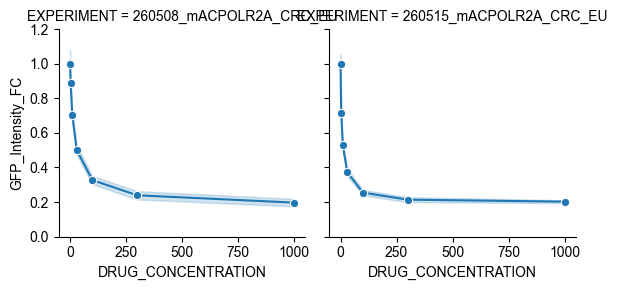

In [19]:
g = sns.FacetGrid(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
                  col = 'EXPERIMENT',
                  ylim = (0,1.2))

g.map_dataframe(sns.lineplot,
                x = 'DRUG_CONCENTRATION',
                y = 'GFP_Intensity_FC',
                errorbar = 'sd',
                marker = 'o')

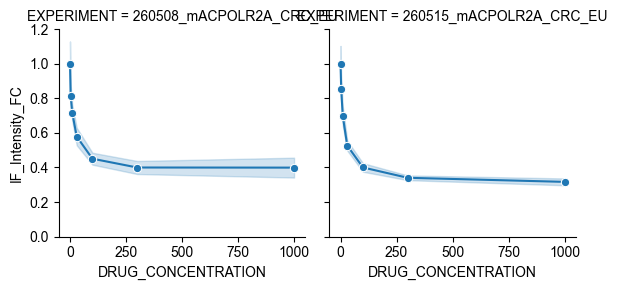

In [20]:
g = sns.FacetGrid(Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
                  col = 'EXPERIMENT',
                  ylim = (0,1.2))

g.map_dataframe(sns.lineplot,
                x = 'DRUG_CONCENTRATION',
                y = 'IF_Intensity_FC',
                errorbar = 'sd',
                marker = 'o')

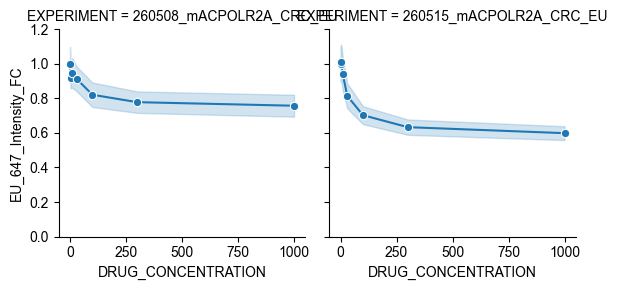

In [21]:
g = sns.FacetGrid(EU_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5"'),
                  col = 'EXPERIMENT',
                  ylim = (0,1.2))

g.map_dataframe(sns.lineplot,
                x = 'DRUG_CONCENTRATION',
                y = 'EU_647_Intensity_FC',
                errorbar = 'sd',
                marker = 'o')

## map drug concentrations to log transformed values

In [22]:
IntensitiesByWell.DRUG_CONCENTRATION.unique()

array([   0, 1000,  300,  100,   30,   10,    3])

In [23]:
IntensitiesByWell['DRUG_CONCENTRATION_LOG'] = IntensitiesByWell.DRUG_CONCENTRATION.map(dict(zip([0, 1000, 300, 100, 30, 10, 3], [-12, -6, -6.5, -7, -7.5, -8, -8.5])))
Total_IntensitiesByWell['DRUG_CONCENTRATION_LOG'] = Total_IntensitiesByWell.DRUG_CONCENTRATION.map(dict(zip([0, 1000, 300, 100, 30, 10, 3], [-12, -6, -6.5, -7, -7.5, -8, -8.5])))
EU_IntensitiesByWell['DRUG_CONCENTRATION_LOG'] = EU_IntensitiesByWell.DRUG_CONCENTRATION.map(dict(zip([0, 1000, 300, 100, 30, 10, 3], [-12, -6, -6.5, -7, -7.5, -8, -8.5])))

# plots for manuscript

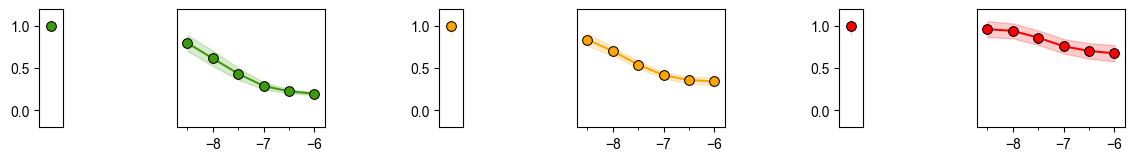

In [24]:
f, a = plt.subplots(ncols = 6, figsize = (12,1.5), layout = 'constrained')

sns.lineplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION == 0'),
             x = 'DRUG_CONCENTRATION_LOG',
             y = 'GFP_Intensity_FC',
             errorbar = 'sd',
             marker = 'o',
             markersize = 7,
             markeredgecolor = 'black',
             color = 'xkcd:grass green',
             ax = a[0],
             legend = False)

sns.lineplot(IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION > 0'),
             x = 'DRUG_CONCENTRATION_LOG',
             y = 'GFP_Intensity_FC',
             errorbar = 'sd',
             marker = 'o',
             markersize = 7,
             markeredgecolor = 'black',
             color = 'xkcd:grass green',
             ax = a[1])

sns.lineplot(Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION == 0'),
             x = 'DRUG_CONCENTRATION_LOG',
             y = 'IF_Intensity_FC',
             errorbar = 'sd',
             marker = 'o',
             markersize = 7,
             markeredgecolor = 'black',
             color = 'orange',
             ax = a[2],
             legend = False)

sns.lineplot(Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION > 0'),
             x = 'DRUG_CONCENTRATION_LOG',
             y = 'IF_Intensity_FC',
             errorbar = 'sd',
             marker = 'o',
             markersize = 7,
             markeredgecolor = 'black',
             color = 'orange',
             ax = a[3])

sns.lineplot(EU_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION == 0'),
             x = 'DRUG_CONCENTRATION_LOG',
             y = 'EU_647_Intensity_FC',
             errorbar = 'sd',
             marker = 'o',
             markersize = 7,
             markeredgecolor = 'black',
             color = 'red',
             ax = a[4],
             legend = False)

sns.lineplot(EU_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION > 0'),
             x = 'DRUG_CONCENTRATION_LOG',
             y = 'EU_647_Intensity_FC',
             errorbar = 'sd',
             marker = 'o',
             markersize = 7,
             markeredgecolor = 'black',
             color = 'red',
             ax = a[5])

a[0].set_box_aspect(5)
a[0].set_xticks([])
a[2].set_box_aspect(5)
a[2].set_xticks([])
a[4].set_box_aspect(5)
a[4].set_xticks([])

a[1].set_yticks([])
a[1].set_box_aspect(0.8)
a[1].set_xlim(-8.7,-5.8)
a[1].set_xticks([-8,-7,-6])
a[1].set_xticks([-8.5,-7.5,-6.5], minor = True)

a[3].set_yticks([])
a[3].set_box_aspect(0.8)
a[3].set_xlim(-8.7,-5.8)
a[3].set_xticks([-8,-7,-6])
a[3].set_xticks([-8.5,-7.5,-6.5], minor = True)

a[5].set_yticks([])
a[5].set_box_aspect(0.8)
a[5].set_xlim(-8.7,-5.8)
a[5].set_xticks([-8,-7,-6])
a[5].set_xticks([-8.5,-7.5,-6.5], minor = True)

for i in range(6):
    a[i].set_ylim(-0.2,1.2)
    a[i].set_xlabel('')
    a[i].set_ylabel('')

plt.savefig('mACPOLR2A_CRC_GFP_TotalPolII_EU.svg')

# Total Pol II versus EU incorporation scatterplot

In [25]:
# pull means and standard deviation values for both total Pol II IF and EU, vehicle treated

TotalVehicleMean = Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG == "Vehicle"')['IF_Intensity_FC'].mean()
TotalVehicleSD = Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG == "Vehicle"')['IF_Intensity_FC'].std()

EUVehicleMean = EU_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG == "Vehicle"')['EU_647_Intensity_FC'].mean()
EUVehicleSD = EU_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG == "Vehicle"')['EU_647_Intensity_FC'].std()

# pull means and standard deviation values for both total Pol II IF and EU, grouped by 5PhIAA concentration

TotalGroupedMean = Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION > 0')[['DRUG_CONCENTRATION','IF_Intensity_FC']].groupby(['DRUG_CONCENTRATION']).mean().reset_index()
TotalGroupedSD = Total_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION > 0')[['DRUG_CONCENTRATION','IF_Intensity_FC']].groupby(['DRUG_CONCENTRATION']).std().reset_index()

EUGroupedMean = EU_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION > 0')[['DRUG_CONCENTRATION','EU_647_Intensity_FC']].groupby(['DRUG_CONCENTRATION']).mean().reset_index()
EUGroupedSD = EU_IntensitiesByWell.query('CELL == "HCT116 OsTIRF74G mAC-POLR2A Clone 5" & DRUG_CONCENTRATION > 0')[['DRUG_CONCENTRATION','EU_647_Intensity_FC']].groupby(['DRUG_CONCENTRATION']).std().reset_index()

In [26]:
TotalGroupedMean.rename(columns = {'IF_Intensity_FC' : 'TotalPolII'}, inplace = True)
TotalGroupedSD.rename(columns = {'IF_Intensity_FC' : 'TotalPolII_SD'}, inplace = True)
EUGroupedMean.rename(columns = {'EU_647_Intensity_FC' : 'EU'}, inplace = True)
EUGroupedSD.rename(columns = {'EU_647_Intensity_FC' : 'EU_SD'}, inplace = True)

In [27]:
XYPLOT_EU = TotalGroupedMean.merge(TotalGroupedSD).merge(EUGroupedMean).merge(EUGroupedSD)

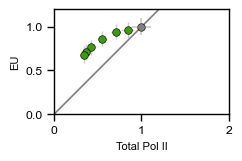

In [28]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (5,1.5), layout = 'constrained')

# plot error bars for vehicle treated point

plt.errorbar(x = [TotalVehicleMean], 
             xerr = [TotalVehicleSD],
             y = [EUVehicleMean], 
             yerr = [EUVehicleSD],
             color = 'grey',
             alpha = 0.4)

# plot error bars for 5-ph-iaa treated points

plt.errorbar(x = XYPLOT_EU.TotalPolII,
             xerr = XYPLOT_EU.TotalPolII_SD,
             y = XYPLOT_EU.EU,
             yerr = XYPLOT_EU.EU_SD,
             linestyle = "None", linewidth = 1,
             color = 'grey', 
             alpha = 0.4, zorder = 1)

# plot vehicle treated point in grey

sns.scatterplot(x = [TotalVehicleMean], y = [EUVehicleMean], color = 'grey', s = 30, edgecolor = 'black')

# plot total and pSer2 at each time and concentration

h = sns.scatterplot(XYPLOT_EU,
                x = 'TotalPolII',
                y = 'EU',
                color = 'xkcd:grass green',
                marker = 'o', s = 30, edgecolor = 'black')

a.set_box_aspect(0.6)
a.set_ylim(0,1.2)
a.set_xlim(0,2)
a.set_xticks([0,1.0,2.0])
a.set_yticks([0,0.5,1,])

a.axline(xy1 = (0,0), slope = 1, color = 'grey', zorder = 0)

a.set_xlabel('Total Pol II', fontsize = 8)

a.set_ylabel('EU', fontsize = 8)

plt.savefig('mACPOLR2A_CRC_TotalPolII_versus_EU.svg')

In [34]:
XYPLOT_EU

,DRUG_CONCENTRATION,TotalPolII,TotalPolII_SD,EU,EU_SD
0,3,0.840334,0.073105,0.964823,0.094329
1,10,0.704617,0.052468,0.944433,0.088845
2,30,0.544184,0.043958,0.863625,0.086110
3,100,0.417151,0.036769,0.762100,0.085700
4,300,0.360244,0.037066,0.705944,0.090980
5,1000,0.344298,0.053082,0.678218,0.096454


In [44]:
CELL_NAME = "HCT116 OsTIRF74G mAC-POLR2A Clone 5"
TIME_COL = "TIME_MINUTES"
TIME_VALUE = 240
INTENSITY_COL = "EU_647_Intensity_FC"

eu = EU_IntensitiesByWell.query("CELL == @CELL_NAME").copy()

# vehicle normalization
eu_vehicle_mean = eu.loc[eu["DRUG"] == "Vehicle", INTENSITY_COL].mean()
eu["Norm_Intensity"] = eu[INTENSITY_COL] / eu_vehicle_mean

# keep only the matched timepoint and treated doses
eu_4h = eu.loc[(eu[TIME_COL] == TIME_VALUE) & (eu["DRUG_CONCENTRATION"] >= 0)].copy()

eu_export = (
    eu_4h.groupby(["DRUG_CONCENTRATION", TIME_COL])["Norm_Intensity"]
    .agg(Mean="mean", SD="std", N="size")
    .reset_index()
)

eu_export.to_csv("mACPOLR2A_CRC_EU_4h_normalized.csv", index=False)
eu_export

,DRUG_CONCENTRATION,TIME_MINUTES,Mean,SD,N
0,0,240,1.000000,0.099601,80
1,3,240,0.964823,0.094329,20
2,10,240,0.944433,0.088845,20
3,30,240,0.863625,0.086110,20
4,100,240,0.762100,0.085700,20
5,300,240,0.705944,0.090980,20
6,1000,240,0.678218,0.096454,20
